# Self-Correcting Agentic Retrieval Loops

**Build an agent that reads its own retrieval, then spends only what each query needs.**

Most retrieval agents do the same thing to every query: one fixed pipeline, whether the question
is a trivial lookup or a hard multi-hop chain. Here you build, from Qdrant primitives, a
**self-evaluating agent** that reads cheap in-loop signals and climbs a **cost-escalation ladder**
only as far as it has to:

```
Tier 1  answer        confident? answer now (the cheap path)
Tier 2  ColBERT       weak single-hop lookup? a token-level precision re-retrieval
Tier 3  decompose     weak multi-hop? recover the missing hop (IRCoT)
        then ANSWER or STOP (a separate sufficiency decision)
```

You build every part here from external primitives (Qdrant, FastEmbed, an LLM): the retrieval, the
signals, the gate, the decompose loop, and the routing are all real code you can read, run, and
adapt. The `src/` package mirrors this same logic for reuse in your own projects, and `src/labkit.py`
handles rendering. We run the agent end-to-end on a **mixed workload** (single-hop, multi-hop, and
unanswerable questions) and measure its cost and quality across all three.

Roadmap: **CP1** the hybrid query + baseline, **CP2** define and benchmark the confidence signals,
**the gate** turn them into a weak/strong decision, **CP3** the ColBERT and decompose tiers run live,
**the assembled loop** run end to end, **STOP** the answer-vs-abstain choice, **Wrap** the
scorecard and how to adapt this to your workflow.

## Setup: run this first, confirm `Ready`

Everything is pre-installed and pre-embedded on your VM. This cell imports the external primitives
(the Qdrant client, the FastEmbed models, the LLM), defines the inline constants the agent uses,
loads the question set, and **warms the embedding models** (FastEmbed fetches them from Hugging Face
the first time; on the prebuilt VM they are already cached, so this is a load). `labkit` from `src/`
handles rendering (printing hits and the two plots); the agent code lives in this notebook.

In [1]:
import sys
import os
import json
import re
import string
import time
import statistics
from pathlib import Path
from dataclasses import dataclass

from dotenv import load_dotenv
import pandas as pd
import numpy as np
import litellm
from qdrant_client import QdrantClient, models
from fastembed import TextEmbedding, SparseTextEmbedding, LateInteractionTextEmbedding
from sklearn.metrics import roc_auc_score

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))    # makes labkit (rendering) importable; the agent code lives in this notebook
load_dotenv(REPO / ".env")
os.environ.setdefault("LITELLM_LOG", "ERROR")
pd.set_option("display.precision", 3)

from labkit import (load_artifact, frontier_table, show_hits, show_run,
                    plot_signal_separation, plot_gate)

# --- inline constants (the collection schema, model ids, retrieval + answer sizes) ---
COLLECTION = "musique"
COLBERT_COLLECTION = "musique_colbert"             # dense + colbert multivector (Tier 2 showcase)
DENSE_MODEL = "BAAI/bge-base-en-v1.5"              # 768-d dense, cosine
MINICOIL_MODEL = "Qdrant/minicoil-v1"             # word-sense-aware sparse (the hybrid baseline's sparse)
COLBERT_MODEL = "answerdotai/answerai-colbert-small-v1"
DENSE_VEC, MINICOIL_VEC, COLBERT_VEC = "dense", "minicoil", "colbert"
RETRIEVE_N = 50          # per-retriever prefetch depth before fusion
TOP_K = 10               # signal / pool window
ANSWER_K = 3             # focused passages the LLM reads to answer (the precision regime)
AGENT_MODEL = "anthropic/claude-sonnet-4-6"        # decompose + answer
FAST_MODEL = "anthropic/claude-haiku-4-5"          # the fast sufficiency autorater (STOP)

client = QdrantClient(url=os.environ.get("QDRANT_URL", "http://localhost:6333"), timeout=120)

# The query-side embedders. The corpus is already indexed in Qdrant; only these query models load here.
dense_model = TextEmbedding(DENSE_MODEL)
minicoil_model = SparseTextEmbedding(MINICOIL_MODEL)
colbert_model = LateInteractionTextEmbedding(COLBERT_MODEL)
for warm in (dense_model, minicoil_model):
    next(iter(warm.query_embed("warm up")))
next(iter(colbert_model.query_embed("warm up")))

# The question set (mixed workload), loaded straight from the dataset file.
by_id = {q["id"]: q for q in (json.loads(line) for line in (REPO / "data/questions_mixed.jsonl").open())}

main_count = client.count(COLLECTION, exact=True).count
assert main_count > 0, "collection empty - run scripts/setup_collections.py"
colbert_count = (client.count(COLBERT_COLLECTION, exact=True).count
                 if client.collection_exists(COLBERT_COLLECTION) else "absent")
api_keys_loaded = all(os.environ.get(k) for k in ("ANTHROPIC_API_KEY", "OPENAI_API_KEY"))

print(f"Qdrant '{COLLECTION}': {main_count} points  |  '{COLBERT_COLLECTION}': {colbert_count} points")
print(f"dense ({DENSE_MODEL}) + sparse (minicoil), fused with RRF")
print(f"loaded {len(by_id)} questions; embedding models warm; answer context = top-{ANSWER_K}")
print(f"API keys loaded: {api_keys_loaded}")
print("\nReady" if main_count and api_keys_loaded else "\nNOT ready")

17:51:12 - LiteLLM:WARNING: common_utils.py:979 - litellm: could not pre-load bedrock-runtime response stream shape — Bedrock event-stream decoding will be unavailable. Error: No module named 'botocore'


17:51:12 - LiteLLM:WARNING: common_utils.py:24 - litellm: could not pre-load sagemaker-runtime response stream shape — SageMaker event-stream decoding will be unavailable. Error: No module named 'botocore'


Qdrant 'musique': 22808 points  |  'musique_colbert': 22808 points
dense (BAAI/bge-base-en-v1.5) + sparse (minicoil), fused with RRF
loaded 2612 questions; embedding models warm; answer context = top-3
API keys loaded: True

Ready


## The LLM call

The agent uses an LLM for exactly three focused jobs, all routed through one helper: writing the
next decompose sub-question (CP1, CP3), generating the final grounded answer (the assembled loop),
and the sufficiency autorater (STOP). Here is that single helper. It is deterministic at
`temperature=0` and retries a few times on transient API errors so one network blip does not kill a
live run.

In [2]:
def ask_llm(system, user, max_tokens=256, model=AGENT_MODEL, temperature=0.0):
    # one LLM turn via LiteLLM. Returns the message text. Deterministic at temperature 0.
    litellm.suppress_debug_info = True
    for attempt in range(4):
        try:
            resp = litellm.completion(
                model=model,
                messages=[{"role": "system", "content": system},
                          {"role": "user", "content": user}],
                max_tokens=max_tokens, temperature=temperature, timeout=45,
            )
            return (resp.choices[0].message.content or "").strip()
        except Exception:
            if attempt == 3:
                raise
            time.sleep(2 ** attempt)

## CP1: the hybrid query, the precision regime, and the baseline

Real traffic is **mixed**: easy single-hop lookups, hard multi-hop chains, and unanswerable
questions. The **baseline** runs one hybrid retrieve, then answers. The key design choice: the agent
answers from a **focused top-3 context**, so ranking *precision* (recall@1/@3) is what matters, and it
gives the corrective tiers room to work.

> **On your data:** set this answer-context size deliberately. At top-10 an easy lookup is already
> solved; at top-3 the ranking has to be precise, which gives the corrective tiers real headroom.

First, the retrieval primitive. `embed` runs the two query-side encoders; `hybrid_search` is the
actual Qdrant **hybrid** query: dense (bge) and sparse (miniCOIL) prefetched in parallel, then fused
server-side with Reciprocal Rank Fusion. We also define the lightweight `Passage` the rest of the
loop reads. We will reuse all of this everywhere.

In [3]:
def embed(text):
    # the two query-side embeddings used everywhere: dense (bge) + miniCOIL sparse. query_embed
    # applies the bge query instruction and the sparse query-side weighting; Qdrant applies IDF.
    dense = next(iter(dense_model.query_embed(text))).tolist()
    minicoil = next(iter(minicoil_model.query_embed(text)))
    return dense, minicoil

def hybrid_search(question, limit=TOP_K, enc=None):
    # Qdrant hybrid retrieval: dense + miniCOIL prefetched (top-50 each), fused server-side with RRF.
    dense, minicoil = enc or embed(question)
    return client.query_points(
        COLLECTION,
        prefetch=[
            models.Prefetch(query=dense, using=DENSE_VEC, limit=RETRIEVE_N),
            models.Prefetch(
                query=models.SparseVector(indices=minicoil.indices.tolist(),
                                          values=minicoil.values.tolist()),
                using=MINICOIL_VEC, limit=RETRIEVE_N),
        ],
        query=models.FusionQuery(fusion=models.Fusion.RRF),
        limit=limit, with_payload=True,
    ).points

@dataclass
class Passage:
    # the lightweight passage object the answerer and the decompose pooler read.
    doc_id: str
    title: str
    text: str
    score: float

def to_passages(points):
    return [Passage(p.id, p.payload["title"], p.payload["text"], p.score) for p in points]

### Two kinds of query, and why you can't tell them apart up front

Both of these are perfectly normal things a user asks, and on the surface they look the same:

- **Simple (single-hop):** the answer sits in one passage, so a single retrieve can answer it
  right away. *"Which continent is the Atbarah River on?"*
- **Complex (multi-hop):** the answer is spread across passages, and the later ones are not
  reachable from the question as written. The agent has to retrieve, read what came back, and
  retrieve again. *"What sea washes the shores of the birthplace of Jim Wilson?"* needs the
  birthplace before it can ask about the sea.

Nothing on the surface of a question reliably says "this one needs a second hop," so you cannot
sort them up front. That is exactly why the agent reads a cheap signal off its own retrieval (CP2)
and escalates only when the retrieval looks weak, instead of trusting the question.

A single-hop lookup first: the supporting passage is right there, so the agent answers from the
top-3.

In [4]:
single = by_id["2hop__101521_42157__h0"]
print(f"Q: {single['question']}\n")
show_hits(hybrid_search(single["question"]), single["gold_doc_ids"])

Q: Which continent is Atbarah River located?

  [GOLD] #1  Atbarah River
            The Atbarah River (; transliterated: Nahr 'Atbarah) in northeast Africa rises in northwest Ethi...
  [    ] #2  Tekezé River
            The Tekezé River rises in the central Ethiopian Highlands near Mount Qachen within Lasta, from ...
  [    ] #3  Nile
            The Nile (Arabic: النيل‎, written as al-Nīl; pronounced as an-Nīl) is a major north-flowing riv...


Now a multi-hop question. The follow-up hop is written by the agent's **decomposer**, an LLM step we
define right here (CP3 builds it into the full tier). Given the main question and the evidence so far,
it asks the next still-missing sub-question, or says `ENOUGH`. That iterative retrieve-read-ask cycle
is **IRCoT**:

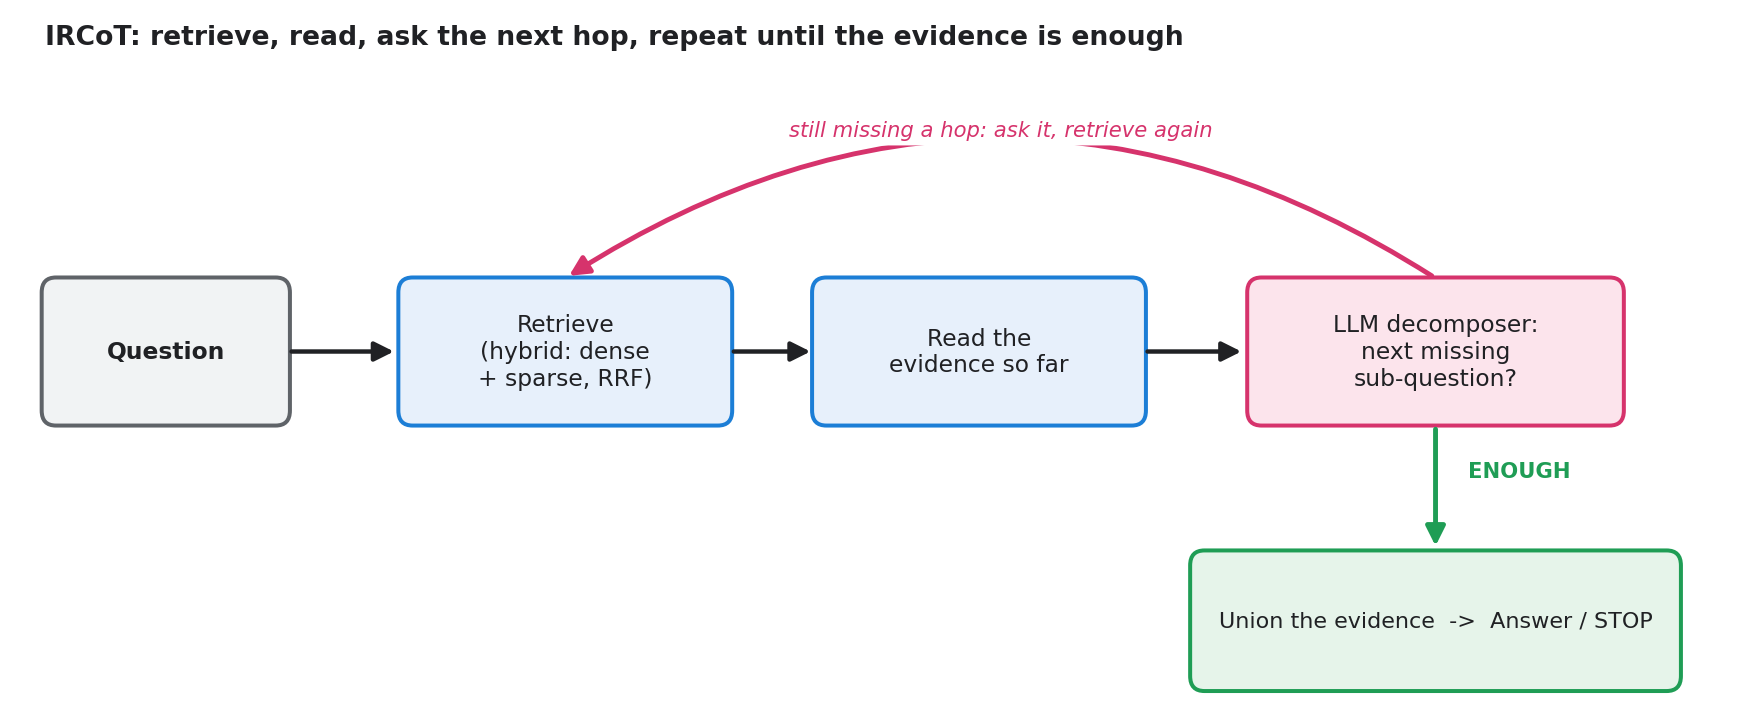

*The IRCoT loop. CP1 below runs a single pass of it (one follow-up hop); CP3 closes the loop into `decompose()`.*

In [5]:
IRCOT_SYSTEM = (
    "You are running an iterative retrieve-and-reason loop to answer a multi-hop "
    "question. Given the main question, the evidence retrieved so far, and the "
    "sub-questions already asked, output the NEXT single sub-question whose answer is "
    "still MISSING and is needed to answer the main question. Make it self-contained: "
    "name entities explicitly, resolving any bridge entity from the evidence so far. "
    "If the evidence already contains everything needed to answer the main question, "
    "reply with exactly: ENOUGH. Output ONLY the sub-question text or ENOUGH - no prose."
)

def evidence_digest(pools, max_docs=6, max_chars=160):
    # a short, deduped digest of the evidence retrieved so far, to condition the next sub-query.
    seen, lines = set(), []
    for pool in pools:
        for c in pool:
            if c.doc_id in seen:
                continue
            seen.add(c.doc_id)
            lines.append(f"- {c.title}: {(c.text or '')[:max_chars]}")
            if len(lines) >= max_docs:
                return "\n".join(lines)
    return "\n".join(lines) if lines else "(none)"

def next_subquery(question, pools, sub_queries):
    # the LLM reads the evidence so far and asks the next still-missing sub-question (or ENOUGH).
    user = (
        f"Main question: {question}\n\n"
        f"Evidence so far:\n{evidence_digest(pools)}\n\n"
        "Sub-questions already asked:\n" + ("\n".join(f"- {s}" for s in sub_queries) or "(none)") +
        "\n\nNext sub-question (or ENOUGH):"
    )
    text = ask_llm(IRCOT_SYSTEM, user, max_tokens=80)
    t = (text or "").strip()
    if not t or t.upper().startswith("ENOUGH"):
        return None
    return re.sub(r"^[\-\d\.\)\s]+", "", t.splitlines()[0]).strip() or None

Watch what one retrieve can and cannot reach on the Jim Wilson question:

> *What sea washes on the shores of the birthplace of Jim Wilson?*

- **Hop 1 (the birthplace):** retrieve the question as written -> County Antrim
- **Hop 2 (the sea):** the decomposer reads Hop 1 and asks the still-missing question -> Irish Sea

In [6]:
multi = by_id["2hop__615262_131886"]
gold = set(multi["gold_doc_ids"])

# HOP 1: retrieve the question as written; look deep (top-100) for the second passage.
hop1 = hybrid_search(multi["question"], limit=100)
print(f"Q: {multi['question']}\n")
print("HOP 1 - retrieve the question as written (top-3):")
show_hits(hop1, gold)

missing = gold - {p.id for p in hop1[:3]}
reachable_deep = bool(missing & {p.id for p in hop1})
print(f"supporting passages in the top-3: {len(gold) - len(missing)}/{len(gold)} "
      f"(only the Hop-1 passage, whose snippet names the birthplace).")
print(f"the missing Hop-2 passage is {'in' if reachable_deep else 'NOT in'} the fused top-100 "
      f"(in neither retriever's top-50): genuinely out of reach, not just mis-ranked.\n")

# HOP 2: let the decomposer write the follow-up (its real LLM step), then retrieve it.
hop2_query = next_subquery(multi["question"], [to_passages(hop1[:TOP_K])], [])
print(f'HOP 2 - the decomposer reads Hop 1 and asks:  "{hop2_query}"')
show_hits(hybrid_search(hop2_query), gold)

Q: What sea washes on the shores of the birthplace of Jim Wilson?

HOP 1 - retrieve the question as written (top-3):
  [GOLD] #1  Jim Wilson (Northern Ireland politician)
            Born in County Antrim, Wilson attended Belfast College of Technology before becoming a marine e...
  [    ] #2  Beaufort Sea
            The Beaufort Sea () is a marginal sea of the Arctic Ocean, located north of the Northwest Terri...
  [    ] #3  SS Keno
            The SS "Keno" is a preserved historic sternwheel paddle steamer and National Historic Site of C...
supporting passages in the top-3: 1/2 (only the Hop-1 passage, whose snippet names the birthplace).
the missing Hop-2 passage is NOT in the fused top-100 (in neither retriever's top-50): genuinely out of reach, not just mis-ranked.



HOP 2 - the decomposer reads Hop 1 and asks:  "What sea washes the shores of County Antrim?"
  [GOLD] #1  County Antrim
            In ancient times, Antrim was inhabited by a Celtic people called the Darini. In the early Middl...
  [    ] #2  Toome Upper
            Toome Upper is a barony in County Antrim, Northern Ireland. To its south lies Lough Neagh, and ...
  [    ] #3  Massereene Lower
            Massereene Lower is a barony in County Antrim, Northern Ireland. To its west lies Lough Neagh, ...


So the answer needed **two** retrievals, and the decomposer could only write the second after Hop 1
revealed the bridge entity (County Antrim). That is a **recall** gap, not a ranking one. The
baseline does only the first retrieve, which is why multi-hop is its weak spot. CP3 wraps this
generate-and-retrieve step into the full `decompose()` tier (looping over hops, unioning evidence).

## CP2: confidence signals, reading the retrieval

A **confidence signal** (or weakness signal) is a cheap scalar you read off the retrieval result to
estimate one thing: is this good enough to answer from, or should I spend more? The agent reads it at
tier 1, before it has paid for any correction.

That "before" is the whole constraint. The signal runs on **every** query, ahead of the decision to
escalate, so it has to be **near-instant**: read from what you already retrieved, or at most one
extra cheap query. A signal that costs as much as the fix it gates buys you nothing. So a candidate
earns its place on **two** axes:

1. **Does it separate** good retrievals from weak ones? (its discriminative power, measured by the AUC below)
2. **Is it cheap?** (near-instant, or it defeats the purpose)

We test a handful of candidates on both, on this corpus, and keep only what survives. The selection
is the lesson; the winners are corpus-specific (more on that below).

### The candidates, by family

Five candidates, each reading a different facet of one retrieval:

| family | signal | what it reads | flags weak when | tends to matter on |
|---|---|---|---|---|
| height | `max_score` | top-1 fused score | low | score-calibrated single-retriever setups |
| spread (fused) | `score_variance` | spread of the fused top-k scores | low (flat ranking) | corpora where fusion keeps score range |
| spread (raw) | `dense_variance` | spread of the **raw dense** cosines | low (dense can't separate its hits) | most dense-retrieval corpora |
| coverage | `evidence_coverage` | question entities present in the top-k text | low (text misses them) | entity-lookup / keyword data |
| agreement | `retriever_divergence` | dense vs miniCOIL top-k overlap | high (they disagree) | lexical-mismatch / jargon / OOV data |

**Raw dense vs fused** is the design choice that matters most. Spread can be read on the fused RRF
score or on the raw dense cosines. RRF compresses scores into ranks and throws the spread away, so
the *fused* version is blunt while the *raw-dense* version keeps its dynamic range. We benchmark both,
and the benchmark below crowns the raw-dense one. (We do *not* separately benchmark the rank-1-minus-
rank-K "gap": it measures the same thing as spread and runs ~0.99 correlated with it, so `variance`
stands in for both. That is the easy redundancy. The interesting one is below.)

**These differ in cost**, and that is the second axis. `max_score`, `score_variance`, and
`evidence_coverage` are free: they read the hybrid result you already have. `dense_variance` and
`retriever_divergence` each cost one extra single-retriever query, reusing embeddings the hybrid query
already computed (no extra model). We read divergence against miniCOIL, the sparse retriever already in
the hybrid query, rather than loading a separate BM25; a maximally-lexical retriever like BM25 is often
a sharper divergence detector, and is what you would reach for on data where this signal earns its
keep.

First, the materials the signals read: we already have the fused hybrid result, so we add the two raw
single-retriever rankings (dense and miniCOIL) and the teaching-simple entity extractor coverage uses.

In [7]:
def dense_ranking(question, enc=None):
    # the RAW dense cosine ranking (a dense-only Qdrant query), pre-fusion: [(doc_id, cosine), ...].
    dense, _minicoil = enc or embed(question)
    pts = client.query_points(COLLECTION, query=dense, using=DENSE_VEC, limit=TOP_K, with_payload=False).points
    return [(p.id, p.score) for p in pts]

def minicoil_ranking(question, enc=None):
    # the RAW miniCOIL ranking (a sparse-only Qdrant query), pre-fusion: [doc_id, ...]. Reuses the
    # miniCOIL embedding the hybrid query already computes, so it costs one query, not a new model.
    _dense, minicoil = enc or embed(question)
    pts = client.query_points(
        COLLECTION,
        query=models.SparseVector(indices=minicoil.indices.tolist(), values=minicoil.values.tolist()),
        using=MINICOIL_VEC, limit=TOP_K, with_payload=False).points
    return [p.id for p in pts]

_QUESTION_STOP = {"what", "who", "whom", "whose", "where", "when", "which", "why", "how",
                  "is", "was", "are", "were", "did", "do", "does", "the", "a", "an", "name",
                  "in", "of", "on", "at", "to", "for", "by", "as", "that", "this"}
_NAME_CONNECTORS = {"of", "the", "and", "de", "von", "van", "del", "la", "el", "da", "di", "&"}

def question_entities(question):
    # teaching-simple entity extractor: maximal runs of Capitalized tokens (joined by lowercase
    # connectors like 'of'/'the'), plus 4-digit years; drop the sentence-initial question word.
    # The production upgrade is spaCy NER (mentioned in the docs, not a live dependency here).
    toks = (question or "").split()
    ents, cur = [], []
    for i, tok in enumerate(toks):
        w = tok.strip(string.punctuation)
        if not w:
            if cur:
                ents.append(" ".join(cur)); cur = []
            continue
        is_cap = w[0].isupper()
        if is_cap and not (i == 0 and w.lower() in _QUESTION_STOP):
            cur.append(w)
        elif cur and w.lower() in _NAME_CONNECTORS and i + 1 < len(toks) \
                and toks[i + 1].strip(string.punctuation)[:1].isupper():
            cur.append(w)
        elif cur:
            ents.append(" ".join(cur)); cur = []
    if cur:
        ents.append(" ".join(cur))
    out = {e.lower() for e in ents if len(e) >= 2}
    out |= set(re.findall(r"\b\d{4}\b", question or ""))
    return out

Now the five candidates, one line each (one row of the table above). `retrieve_signals` runs the
three reads once. Note the split the table flagged: `dense_variance` reads the **raw dense** cosines;
the rest read the **fused** scores or the rankings.

In [8]:
def retrieve_signals(question, enc=None):
    # one encode, three reads: the fused hybrid result + the two raw single-retriever rankings.
    enc = enc or embed(question)
    return hybrid_search(question, enc=enc), dense_ranking(question, enc=enc), minicoil_ranking(question, enc=enc)

def max_score(fused):       return fused[0].score                                  # height: top-1 fused score
def score_variance(fused):  return statistics.pstdev([p.score for p in fused])     # spread of the FUSED scores
def dense_variance(dense):  return statistics.pstdev([s for _, s in dense])        # spread of the RAW DENSE cosines

def evidence_coverage(question, fused):                                            # coverage: question entities present?
    ents = question_entities(question)
    if not ents:
        return 1.0
    blob = " ".join(f"{p.payload['title']} {p.payload['text']}" for p in fused).lower()
    return sum(1 for e in ents if e in blob) / len(ents)

def retriever_divergence(dense, sparse_ids):                                       # agreement: dense vs miniCOIL disjointness
    dense_ids = [i for i, _ in dense]
    return 1.0 - len(set(dense_ids) & set(sparse_ids)) / max(len(dense_ids), len(sparse_ids))

**How we pick which signals to keep, computed live.** A signal earns its place only if it predicts a
weak retrieval, where "weak" means the supporting set is *not* all in the top-3. We know which
retrievals are weak here because this is calibration data with gold labels; at run time we have only
the signals, which is the whole reason to benchmark them against a golden set first. We score each
candidate by its **AUC** at separating good retrievals from weak ones (0.5 = chance, 1.0 = perfect),
using `max(auc, 1 - auc)` so the direction does not matter, over the frozen calibration split right
here (about 150 questions, Qdrant-only, no LLM, roughly a minute). The benchmark below is the real
thing, not a cached table.

In [9]:
# The frozen calibration split (seed 5252) only picks WHICH ~150 questions to score; every signal
# value and label below is computed LIVE. The full_gold@3 label = all gold docs inside the fused top-3.
manifest = json.loads((REPO / "artifacts/mixed_manifest.json").read_text())
cal_sel = manifest["splits"]["calibration"]
cal_ids = [*cal_sel["single"], *cal_sel["multi"], *cal_sel["unanswerable"]]
cal_questions = [by_id[i] for i in cal_ids if by_id[i].get("answerable") and by_id[i].get("gold_doc_ids")]

def feature_row(q):
    fused, dense, sparse_ids = retrieve_signals(q["question"])
    gold = set(q["gold_doc_ids"])
    return {
        "full_gold_label": 1 if gold.issubset({p.id for p in fused[:ANSWER_K]}) else 0,
        "dense_variance": dense_variance(dense), "score_variance": score_variance(fused),
        "max_score": max_score(fused), "evidence_coverage": evidence_coverage(q["question"], fused),
        "divergence_minicoil": retriever_divergence(dense, sparse_ids),
    }

calibration = [feature_row(q) for q in cal_questions]   # ~1 min, no LLM
print(f"benchmarked {len(calibration)} calibration questions live; "
      f"{sum(r['full_gold_label'] for r in calibration)} good / "
      f"{sum(1 - r['full_gold_label'] for r in calibration)} weak retrievals")

benchmarked 150 calibration questions live; 101 good / 49 weak retrievals


The AUC catalog, computed from those live features:

In [10]:
labels = [r["full_gold_label"] for r in calibration]

SIGNAL_COLUMN = {   # signal -> the feature-matrix column it reads (divergence is stored per detector)
    "dense_variance": "dense_variance", "score_variance": "score_variance",
    "max_score": "max_score", "evidence_coverage": "evidence_coverage",
    "retriever_divergence": "divergence_minicoil",
}

def signal_auc(name):
    raw = roc_auc_score(labels, [r[SIGNAL_COLUMN[name]] for r in calibration])
    return max(raw, 1 - raw)            # discriminative power, regardless of direction

aucs = {name: signal_auc(name) for name in SIGNAL_COLUMN}
kept = {"dense_variance", "score_variance"}    # cleared the AUC bar AND held up on a held-out validation split

catalog = pd.DataFrame([
    {"signal": name, "AUC": aucs[name], "verdict": "kept" if name in kept else "dropped"}
    for name in sorted(aucs, key=lambda n: -aucs[n])
])
catalog

,signal,AUC,verdict
0,dense_variance,0.750,kept
1,score_variance,0.698,kept
2,max_score,0.655,dropped
3,evidence_coverage,0.586,dropped
4,retriever_divergence,0.529,dropped


Three of the five drop out, for two different reasons. `retriever_divergence` and `evidence_coverage`
never clear the AUC bar. `max_score` clears it, but it turns out ~0.92 correlated with `score_variance`
on this corpus, so the two are near-duplicates and we keep the stronger one. That second cut is the one
you could not predict in advance: height and spread are distinct ideas that just happen to move
together here. Both cuts, from the same live features:

In [11]:
def abs_corr(a, b):
    return abs(float(np.corrcoef([r[SIGNAL_COLUMN[a]] for r in calibration],
                                 [r[SIGNAL_COLUMN[b]] for r in calibration])[0, 1]))

below_bar = sorted((n for n in aucs if aucs[n] < 0.62), key=lambda n: -aucs[n])
print("below the AUC bar (< 0.62), dropped:")
for n in below_bar:
    print(f"  {n:22s} AUC {aucs[n]:.2f}")

print("\nredundant (|corr| > 0.85 with a signal we keep), dropped:")
print(f"  {'max_score':16s} |corr| {abs_corr('max_score', 'score_variance'):.2f} with score_variance")
print(f"\nkept (distinct and discriminative): {sorted(kept)}")

below the AUC bar (< 0.62), dropped:
  evidence_coverage      AUC 0.59
  retriever_divergence   AUC 0.53

redundant (|corr| > 0.85 with a signal we keep), dropped:
  max_score        |corr| 0.92 with score_variance

kept (distinct and discriminative): ['dense_variance', 'score_variance']


The same benchmark as a picture: each signal's value on good vs weak retrievals. Where the two boxes
pull apart, it separates (high AUC); where they overlap, it does not.

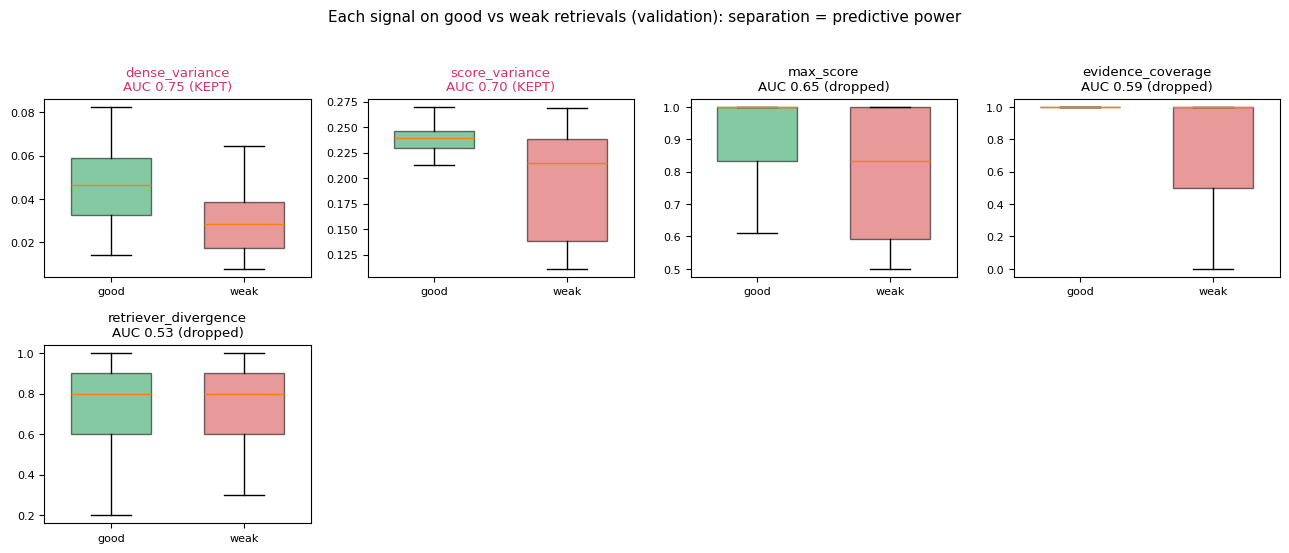

In [12]:
plot_signal_separation(calibration, aucs, kept, SIGNAL_COLUMN)

Two survivors, `dense_variance` and `score_variance`, and they are *not* redundant with each other
(raw-dense vs fused spread correlate only ~0.5), so each earns its place. One discipline to carry over:
we select the signals on a held-out validation split and calibrate the floor below on calibration,
holding test out until the end, so the choice generalizes past the numbers you happen to see here. The deeper
lesson: **the winners are corpus-specific.** On your data the AUCs land differently, a signal weak
here may be strong, and a different set may survive. The method transfers, the selection does not.

## The gate: turning the signals into a decision

Two kept signals, `dense_variance` and `score_variance`. Using them is two steps: **tune** where each
floor sits, then **wire** the gate the loop calls.

### Tuning the floor

Each signal fires when it drops below a floor. We pick that floor live, at the point that maximizes
Youden's J (true-positive rate minus false-positive rate) on the calibration features. Lower the
floor and you escalate less often (higher precision, lower recall); raise it and you catch more weak
retrievals at the cost of escalating some healthy ones.

In [13]:
weak = [r["full_gold_label"] == 0 for r in calibration]    # True = retrieval was weak (gold not all in top-3)

def youden_floor(values):
    # the "fires below" floor that maximizes Youden's J = TPR - FPR over the calibration features.
    best = None
    for thr in sorted(set(values)):
        pred = [v < thr for v in values]
        tp = sum(1 for p, w in zip(pred, weak) if p and w)
        fp = sum(1 for p, w in zip(pred, weak) if p and not w)
        fn = sum(1 for p, w in zip(pred, weak) if not p and w)
        tn = sum(1 for p, w in zip(pred, weak) if not p and not w)
        tpr = tp / (tp + fn) if (tp + fn) else 0.0
        fpr = fp / (fp + tn) if (fp + tn) else 0.0
        if best is None or (tpr - fpr) > best[1]:
            best = (thr, tpr - fpr)
    return best[0]

DV_FLOOR = youden_floor([r["dense_variance"] for r in calibration])
SV_FLOOR = youden_floor([r["score_variance"] for r in calibration])
print(f"calibrated floors:  dense_variance < {DV_FLOOR:.5f}   score_variance < {SV_FLOOR:.5f}\n")

# the operating point of the primary floor, read off the same calibration features
fires = [r["dense_variance"] < DV_FLOOR for r in calibration]
tp = sum(f and w for f, w in zip(fires, weak)); fp = sum(f and not w for f, w in zip(fires, weak))
fn = sum((not f) and w for f, w in zip(fires, weak))
print("at the dense_variance floor:")
print(f"  precision       = {tp / (tp + fp):.3f}   (of the queries we escalate, how many were truly weak)")
print(f"  recall          = {tp / (tp + fn):.3f}   (of the truly weak queries, how many we catch)")
print(f"  escalation rate = {sum(fires) / len(fires):.2f}   (fraction of queries sent past tier 1)")

calibrated floors:  dense_variance < 0.03927   score_variance < 0.23786

at the dense_variance floor:
  precision       = 0.521   (of the queries we escalate, how many were truly weak)
  recall          = 0.776   (of the truly weak queries, how many we catch)
  escalation rate = 0.49   (fraction of queries sent past tier 1)


The same floor as a picture. The left panel shows where it sits on the good vs weak distributions
(escalate to its left); the right panel sweeps it, so you can read precision, recall, and escalation
at any floor, not just the one we chose. `score_variance` works the same way.

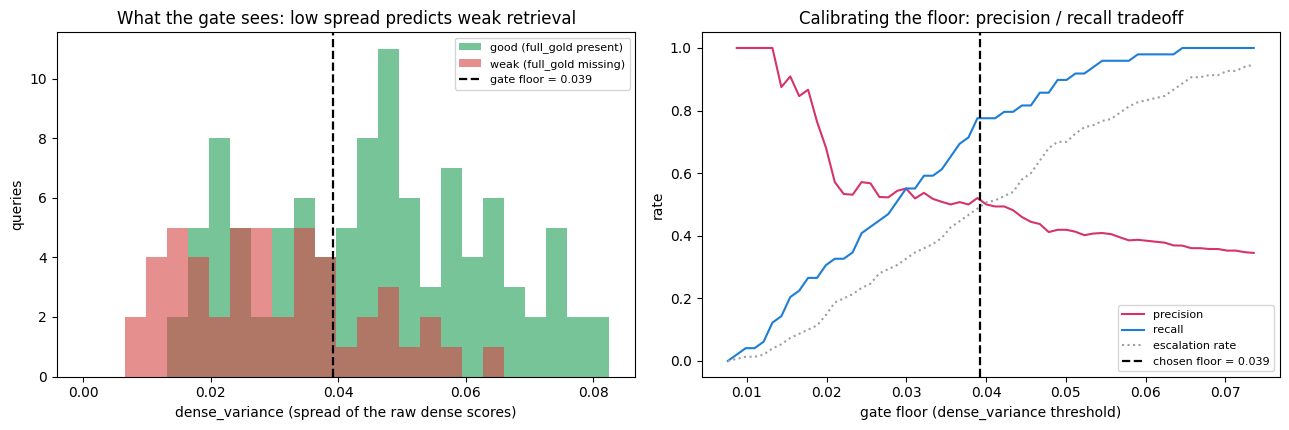

In [14]:
plot_gate(calibration, DV_FLOOR)

### The implementation

The gate the loop calls: escalate if **either** kept signal is below its floor. Its whole cost on top
of the hybrid retrieve you already run is a single dense-only query, exactly the near-instant budget
we set out to keep.

In [15]:
def retrieval_is_weak(question):
    # the tier-1 gate: escalate if EITHER kept signal is below its calibrated floor.
    enc = embed(question)
    dv = dense_variance(dense_ranking(question, enc=enc))
    sv = score_variance(hybrid_search(question, enc=enc))
    return dv < DV_FLOOR or sv < SV_FLOOR

## CP3: the corrective tiers, run live

Each tier is matched to a failure mode. A weak **single-hop** lookup is mis-ranked (a *precision*
problem); a weak **multi-hop** query is missing a hop (a *recall* problem).

### Tier 2: ColBERT late interaction (single-hop precision)

ColBERT scores a query against a passage **token by token** (MaxSim over Qdrant native
multivectors), catching term-level matches a single pooled embedding blurs away. Here is the actual
Qdrant call: prefetch a dense pool, then rescore it with the ColBERT multivector.

In [16]:
def colbert_rerank(question, limit=TOP_K):
    # Qdrant native multivector: prefetch a dense pool, rescore with ColBERT MaxSim (late interaction).
    dense, _minicoil = embed(question)
    colbert_vecs = [v.tolist() for v in next(iter(colbert_model.query_embed(question)))]
    return client.query_points(
        COLBERT_COLLECTION,
        prefetch=[models.Prefetch(query=dense, using=DENSE_VEC, limit=RETRIEVE_N)],
        query=colbert_vecs, using=COLBERT_VEC, limit=limit, with_payload=True,
    ).points

tier2 = by_id["2hop__82744_23140__h0"]            # a weak single-hop lookup
gold = tier2["gold_doc_ids"]
print(f"Q: {tier2['question']}\n")
print("hybrid retrieve, supporting passage buried:")
show_hits(hybrid_search(tier2["question"]), gold)
print("\nColBERT late interaction, the right passage promoted:")
show_hits(colbert_rerank(tier2["question"]), gold)

Q: what country has the largest economy in africa

hybrid retrieve, supporting passage buried:
  [    ] #1  Nigeria
            As of 2015[update], Nigeria is the world's 20th largest economy, worth more than $500 billion a...
  [    ] #2  Nigeria
            Nigeria was ranked 30th in the world in terms of GDP (PPP) in 2012. Nigeria is the United State...
  [    ] #3  Nigeria
            Nigeria is often referred to as the "Giant of Africa", owing to its large population and econom...

ColBERT late interaction, the right passage promoted:
  [GOLD] #1  List of African countries by GDP (nominal)
            2017 Rank Country Nominal GDP ($billions) Nominal GDP per capita (US $) Notes Nigeria 376.284 1...
  [    ] #2  Nigeria
            As of 2015[update], Nigeria is the world's 20th largest economy, worth more than $500 billion a...
  [    ] #3  Namibia
            In 2013, global business and financial news provider, Bloomberg, named Namibia the top emerging...


Hybrid matched the entity "Nigeria" and buried the passage that actually answers the question (the
GDP table); ColBERT pulled it to rank 1. Across the validation set ColBERT is a wash *on average*
(single-hop is already mostly solved), but on the weak lookups the gate routes to it, it lifts
precision. A cross-encoder reranker ties ColBERT here; we use ColBERT because it is a native Qdrant
multivector. On your data, test both.

### Tier 3: decompose (IRCoT) for multi-hop recall

No reranking can fix a *missing* hop. In CP1 you watched the decomposer generate one follow-up and
reach the missing passage; `decompose()` wraps that into a loop: retrieve, ask the next still-missing
sub-question (the CP1 `next_subquery`), retrieve that, and union the evidence, until the LLM says
ENOUGH. Here is the full loop, run live on the same Jim Wilson question.

In [17]:
def union_pool(pools, k=TOP_K):
    # merge the per-hop passage pools, keeping the MAX score per doc, take the top-k. This is what
    # lets a later hop's strongest passage surface into the final set (the missing-hop recovery).
    best = {}
    for pool in pools:
        for c in pool:
            if c.doc_id not in best or c.score > best[c.doc_id].score:
                best[c.doc_id] = c
    return sorted(best.values(), key=lambda c: c.score, reverse=True)[:k]

def decompose(question, max_hops=4):
    # IRCoT: retrieve, ask the next missing sub-question, retrieve, union. Repeat until ENOUGH.
    pools = [to_passages(hybrid_search(question))]
    sub_queries = []
    for _ in range(max_hops - 1):
        next_q = next_subquery(question, pools, sub_queries)
        if next_q is None:
            break
        sub_queries.append(next_q)
        pools.append(to_passages(hybrid_search(next_q)))
    return union_pool(pools, TOP_K), sub_queries

multi = by_id["2hop__615262_131886"]
gold = multi["gold_doc_ids"]
print(f"Q: {multi['question']}\n")
print("hybrid retrieve (single pass), only the first hop is reachable:")
show_hits(hybrid_search(multi["question"]), gold)

pool, sub_queries = decompose(multi["question"])
print("\ndecompose reads hop 1, then asks the still-missing sub-question:")
for sub_question in sub_queries:
    print(f"  -> {sub_question}")
print("\nunioned evidence, the second supporting passage now in context:")
show_hits(pool, gold, k=4)

Q: What sea washes on the shores of the birthplace of Jim Wilson?

hybrid retrieve (single pass), only the first hop is reachable:
  [GOLD] #1  Jim Wilson (Northern Ireland politician)
            Born in County Antrim, Wilson attended Belfast College of Technology before becoming a marine e...
  [    ] #2  Beaufort Sea
            The Beaufort Sea () is a marginal sea of the Arctic Ocean, located north of the Northwest Terri...
  [    ] #3  How to Train Your Dragon
            The first book in the series, following Hiccup as he captures a dragon as a rite of passage and...



decompose reads hop 1, then asks the still-missing sub-question:
  -> What sea or body of water washes the shores of County Antrim, Northern Ireland?

unioned evidence, the second supporting passage now in context:
  [GOLD] #1  Jim Wilson (Northern Ireland politician)
            Born in County Antrim, Wilson attended Belfast College of Technology before becoming a marine e...
  [GOLD] #2  County Antrim
            In ancient times, Antrim was inhabited by a Celtic people called the Darini. In the early Middl...
  [    ] #3  Toome Upper
            Toome Upper is a barony in County Antrim, Northern Ireland. To its south lies Lough Neagh, and ...
  [    ] #4  Glenariff Forest Park
            Glenariff Forest Park is an 1185 hectare (2928 acre) forest in County Antrim, Northern Ireland....


The hybrid pass found the Jim Wilson passage (its snippet names County Antrim); decompose asked the
follow-up and pulled in the passage about its sea. Now the aggregate, measured across the validation
set with a per-query counterfactual. This table comes from the **offline eval** (every policy over
the whole workload with the LLM, ~45 min, run once), the first of four precomputed scorecards.

In [18]:
policy_comparison = load_artifact("policy_comparison_val.json")   # offline eval, run once
overall = policy_comparison["overall"]
multi_hop = policy_comparison["by_type"]["multi_hop"]

pd.DataFrame([
    {"policy": "always-answer (baseline)", "single-hop recall@3": overall["always_answer"]["recall@3"],
     "single-hop MRR": overall["always_answer"]["mrr"], "multi-hop full_gold@3": multi_hop["always_answer"]["full_gold@3"]},
    {"policy": "always-ColBERT", "single-hop recall@3": overall["always_colbert"]["recall@3"],
     "single-hop MRR": overall["always_colbert"]["mrr"], "multi-hop full_gold@3": multi_hop["always_colbert"]["full_gold@3"]},
    {"policy": "always-decompose", "single-hop recall@3": overall["always_decompose"]["recall@3"],
     "single-hop MRR": overall["always_decompose"]["mrr"], "multi-hop full_gold@3": multi_hop["always_decompose"]["full_gold@3"]},
])

,policy,single-hop recall@3,single-hop MRR,multi-hop full_gold@3
0,always-answer (baseline),0.789,0.859,0.18
1,always-ColBERT,0.799,0.870,0.22
2,always-decompose,0.871,0.874,0.48


## The assembled loop: `solve()`

Now put it together. The whole agent is this one function: retrieve, read the signal, climb only as
far as the query needs. Every piece below is something you built above, including `generate_answer`
(the grounded answer step, defined here), which reads only the focused top-3 and self-abstains with
`INSUFFICIENT_CONTEXT` when the evidence is not enough.

In [19]:
ANSWER_SYSTEM = (
    "You answer a question using ONLY the numbered context passages provided. "
    "Reply with ONLY the final answer on a single line: a name, date, number, or short "
    "noun phrase, usually one to six words. Do NOT show reasoning or steps, do NOT "
    "restate the question, do NOT write 'I need to find', do NOT explain. Output just "
    "the answer text. If the passages do not contain the information needed to answer, "
    "reply with exactly: INSUFFICIENT_CONTEXT"
)

def generate_answer(question, passages):
    # Claude answers grounded in the focused top-ANSWER_K passages, or emits INSUFFICIENT_CONTEXT.
    if not passages:
        return "INSUFFICIENT_CONTEXT"
    ctx = "\n".join(f"[{i}] {c.title}. {(c.text or '')[:700]}"
                    for i, c in enumerate(passages[:ANSWER_K], 1))
    text = ask_llm(ANSWER_SYSTEM, f"Context:\n{ctx}\n\nQuestion: {question}\nAnswer (answer only):",
                   max_tokens=150)
    t = (text or "").strip()
    if "INSUFFICIENT_CONTEXT" in t.upper() or not t:
        return "INSUFFICIENT_CONTEXT"
    last = [ln.strip() for ln in t.splitlines() if ln.strip()][-1]
    return re.sub(r"^(answer|the answer is|final answer)[:\-\s]+", "", last, flags=re.I).strip()

def looks_multi_hop(question):
    # cheap, gold-free router: >= 2 named entities or a long question -> likely a missing hop.
    return len(question_entities(question)) >= 2 or len(question.split()) >= 12

def solve(question):
    # the self-correcting retrieval loop: read the signal, climb only as far as the query needs.
    if not retrieval_is_weak(question):
        return to_passages(hybrid_search(question)), "tier 1: confident, answer from the hybrid top-3"
    if looks_multi_hop(question):
        pool, sub_queries = decompose(question)
        return pool, f"tier 3: weak + multi-hop, decomposed ({len(sub_queries)} sub-question(s))"
    return to_passages(colbert_rerank(question)), "tier 2: weak single-hop, ColBERT late-interaction"

Three queries, three paths from one agent. Each answer is generated from the routed top-3, so this
runs the full loop live.

In [20]:
routing_demos = [
    ("confident single-hop", "2hop__101521_42157__h0"),
    ("weak single-hop",      "2hop__130545_45439__h0"),
    ("multi-hop",            "2hop__615262_131886"),
]
for label, qid in routing_demos:
    q = by_id[qid]
    pool, route = solve(q["question"])
    answer = generate_answer(q["question"], pool)
    print(f"[{label}]")
    show_run(q["question"], route, answer, pool, q["gold_doc_ids"])

[confident single-hop]
Q: Which continent is Atbarah River located?
  route:  tier 1: confident, answer from the hybrid top-3
  answer: Africa
  gold in the answer context: 1/1



[weak single-hop]
Q: What state is Chesapeake City Bridge located?
  route:  tier 2: weak single-hop, ColBERT late-interaction
  answer: Maryland
  gold in the answer context: 1/1



[multi-hop]
Q: What sea washes on the shores of the birthplace of Jim Wilson?
  route:  tier 3: weak + multi-hop, decomposed (1 sub-question(s))
  answer: Irish Sea
  gold in the answer context: 2/2



The cheap query answered at tier 1, the weak lookup escalated to ColBERT, the multi-hop decomposed.
The signal decides how far to climb, so each query pays only for the correction it needs. Now the
cost/quality frontier across the validation set (cost = mean LLM sub-query calls per query;
decompose is the expensive tier; ColBERT adds a retrieval pass, not an LLM call, so it reads ~0
here).

In [21]:
frontier_validation = frontier_table(overall, mrr_key="mrr", cost_key="cost_llm")
frontier_validation

,policy,recall@3,full_gold@3,MRR,LLM calls/query
0,always-answer,0.789,0.673,0.859,0.000
1,always-colbert,0.799,0.693,0.870,0.000
2,always-decompose,0.871,0.787,0.874,1.047
3,ladder,0.852,0.753,0.910,0.467


Read this as a cost/quality tradeoff. The ladder reaches about the same answerable quality as
always-decompose at **under half** the LLM cost, and **leads on MRR**; always-decompose **leads on
full_gold@3** (completeness). The ladder is the cost-efficient point on the frontier.

## The STOP decision: a smaller, separate lever

Stopping is a different decision from routing: whether to answer at all or abstain. The **gentle
stop** is the default (the generator answers, or says it lacks enough), and it keeps the most
answers. For workloads where abstaining out of caution beats a confident wrong answer, swap in an
**LLM sufficiency check**: it catches far more unanswerables but over-refuses some answerables. Here
is that autorater, one fast-model call.

In [22]:
SUFFICIENCY_SYSTEM = (
    "You judge whether the provided context contains ENOUGH information to answer the "
    "question with certainty. First decompose the question into the facts it requires; "
    "the context is SUFFICIENT only if EVERY required fact is explicitly present in the "
    "context. Use ONLY the context, not outside knowledge. If any required fact is "
    'missing, it is insufficient. Reply ONLY with compact JSON: {"sufficient": true|false}.'
)

def sufficiency_judge(question, passages):
    # the STOP autorater: does the retrieved context contain every fact the question requires?
    if not passages:
        return False
    ctx = "\n".join(f"[{i}] {c.title}. {(c.text or '')[:600]}" for i, c in enumerate(passages, 1))
    user = f"Question: {question}\n\nContext:\n{ctx}\n\nIs the context sufficient to answer the question?"
    try:
        text = ask_llm(SUFFICIENCY_SYSTEM, user, max_tokens=512, model=FAST_MODEL)
        m = re.search(r'"?sufficient"?\s*[:=]\s*"?(true|false)"?', text, re.I)
        if m:
            return m.group(1).lower() == "true"
        return bool(json.loads(text[text.find("{"): text.rfind("}") + 1]).get("sufficient"))
    except Exception:    # default to sufficient (do not over-abstain) on a parse/API failure
        return True

The two stops side by side across the workload (the second precomputed **offline-eval** scorecard).
"Full workload handled" counts a query as handled when the agent answers correctly OR correctly
refuses an unanswerable.

In [23]:
stop_variants = load_artifact("targeted_stop_v25.json")["variants"]   # offline eval, run once
stop_rows = [
    ("hybrid baseline + gentle",       "baseline_hybrid_gentle"),
    ("ladder + gentle (default)",      "ladder_gentle"),
    ("ladder + LLM sufficiency check", "ladder_autorater_all"),
]
pd.DataFrame([
    {"setup": label,
     "catches unanswerable": stop_variants[key]["abstain_unans"],
     "over-refuses answerable": stop_variants[key]["false_stop_ans"],
     "full workload handled": stop_variants[key]["selective_accuracy"]}
    for label, key in stop_rows
])

,setup,catches unanswerable,over-refuses answerable,full workload handled
0,hybrid baseline + gentle,0.546,0.211,0.530
1,ladder + gentle (default),0.411,0.150,0.498
2,ladder + LLM sufficiency check,0.865,0.411,0.629


Routing and stopping are separate decisions, and retrieval completeness caps both: a strong router
still needs a deliberate stop policy. Here are both stops on an unanswerable, run live: the agent
decomposes, the gentle stop self-abstains, and the autorater independently judges the context insufficient.

In [24]:
unanswerable = by_id["2hop__108098_170204"]
pool, route = solve(unanswerable["question"])
gentle = generate_answer(unanswerable["question"], pool)
sufficient = sufficiency_judge(unanswerable["question"], pool[:ANSWER_K])
show_run(unanswerable["question"], route, gentle, pool, [])
print(f"  autorater sufficiency check: {'sufficient' if sufficient else 'insufficient -> abstain'}")

Q: Who is the brother of the painter of Metaphysical Interior with Biscuits?
  route:  tier 3: weak + multi-hop, decomposed (2 sub-question(s))
  answer: INSUFFICIENT_CONTEXT

  autorater sufficiency check: insufficient -> abstain


## Wrap: the scorecard (held-out test)

The adaptive ladder against the fixed policies on the test slice (the third precomputed
**offline-eval** scorecard). We lead with retrieval precision (the contamination-resistant measure of
what the loop fixes) and report answer quality with a semantic judge. One caveat to disclose: this
test slice reuses some questions from earlier rounds (see `headline_final_v25.json`), so treat it as
held out from threshold tuning rather than a fresh never-seen set.

In [25]:
headline = load_artifact("headline_final_v25.json")    # offline eval, run once
frontier_test = frontier_table(headline["overall"], mrr_key="mrr_first", cost_key="llm_calls")
frontier_test

,policy,recall@3,full_gold@3,MRR,LLM calls/query
0,always-answer,0.817,0.700,0.880,0.000
1,always-colbert,0.802,0.683,0.892,0.000
2,always-decompose,0.877,0.794,0.901,1.883
3,ladder,0.852,0.761,0.913,0.778


Answer quality uses a **gpt-5.5 semantic judge** that credits correct paraphrases (the fourth
precomputed **offline-eval** scorecard).

In [26]:
judge = load_artifact("judge_eval_v25.json")    # offline eval, run once
by_policy = judge["by_policy"]
answer_quality = pd.DataFrame([
    {"policy": name.replace("_", "-"),
     "overall": by_policy[name]["overall"]["judge"],
     "single-hop": by_policy[name]["single_hop"]["judge"],
     "multi-hop": by_policy[name]["multi_hop"]["judge"]}
    for name in ("always_answer", "ladder", "always_decompose")
])
answer_quality

,policy,overall,single-hop,multi-hop
0,always-answer,0.639,0.833,0.250
1,ladder,0.678,0.825,0.383
2,always-decompose,0.711,0.833,0.467


### What we learned

- **Adaptive routing wins on cost.** The ladder matches always-decompose's answerable quality at about
  40% of its LLM cost and leads on MRR. Always-decompose leads on full_gold@3 (completeness): pick the
  ladder when cost per query matters, decompose when total recall does.
- **The gains concentrate on the hard slice.** Decomposition lifts multi-hop full_gold and multi-hop
  answer quality by tens of points. The overall lift stays small because the single-hop majority is
  already strong, and that is the cost story: easy queries stay cheap.
- **The substrate makes the signal.** Reading spread on the raw dense cosines, before RRF flattens it,
  is what gave the confidence gate its separating power.
- **Routing and stopping are separate levers.** An LLM sufficiency check handles about 0.63 of the full
  workload versus the baseline's 0.53, trading some answers for more correct refusals. Retrieval
  completeness caps both.
- **Decompose's lift is an upper bound.** IRCoT writes its sub-questions with an LLM that may already
  know the bridge entities, so the lift shrinks on an unseen corpus. Recalibrate on yours.

**Signals and actions to test on your own data.** Each suits a workload different from this one:
`evidence_coverage` and `retriever_divergence` (single-hop, entity-lookup, or lexical-mismatch data);
`max_score` (a calibrated single-retriever quality signal); a cross-encoder reranker (matched ColBERT
here); and the recall@10 framing (top-3 surfaces the ranking headroom that recall@10 hides, since
single-hop is ~98% solved at top-10).

### How to adapt this to your workflow

The numbers are ours; the method is yours. To build a self-correcting loop on your own corpus:

1. **Set your answer-context size.** Decide how many passages the LLM reads (we used top-3). That
   choice is what makes ranking precision matter and gives the tiers room to work.
2. **Build candidate signals and validate them.** Compute cheap query-time readings, score each
   against your golden set (AUC), drop the redundant twins, keep what separates on your data. Select
   on one split, calibrate the threshold on another, and hold test out until the end.
3. **Match each tier to a real failure mode.** Inspect your own traces, find your failure modes,
   and pick the cheapest action that fixes each.
4. **Measure on cost AND quality, per query.** Run every policy on every query, read the frontier,
   keep the loop only where it earns its cost.
5. **Choose your stop.** Gentle by default; an LLM sufficiency check when a confident wrong answer
   is more expensive than a correct refusal.

Take home: this notebook, plus the `src/` package that mirrors it for reuse.